In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import matplotlib.image as mpimg
import numpy as np
from PIL import Image
import io, base64

# ── Colors ──────────────────────────────────────────────
COBALT       = '#2D6A9F'
COBALT_DARK  = '#1B4F8A'
COBALT_LIGHT = '#B5D4F4'
CYAN         = '#48B5C4'
CYAN_LIGHT   = '#E8F7F9'
CYAN_DARK    = '#085041'
CYAN_MID     = '#0F6E56'
GRAY_BORDER  = '#CBD5E1'
GRAY_TEXT    = '#64748B'
DARK_TEXT    = '#1e3a5f'

# ── Helper: rounded box ─────────────────────────────────
def rbox(ax, x, y, w, h, fc, ec, lw=1.0, radius=0.015, alpha=1.0):
    p = FancyBboxPatch((x, y), w, h,
                       boxstyle=f'round,pad=0,rounding_size={radius}',
                       fc=fc, ec=ec, lw=lw, zorder=3, alpha=alpha,
                       transform=ax.transData)
    ax.add_patch(p)

# ── Helper: arrow ───────────────────────────────────────
def arrow(ax, x1, y1, x2, y2, color=COBALT):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color=color, lw=1.4),
                zorder=5)

# ── Helper: load image from base64 ──────────────────────
def b64_to_array(b64str):
    img_bytes = base64.b64decode(b64str)
    img = Image.open(io.BytesIO(img_bytes)).convert('RGB')
    return np.array(img)

# ── Load images ─────────────────────────────────────────
# REPLACE these base64 strings with your own images if needed
SLIDE_B64   = '...'
PATCH_B64S  = ['...']

slide_arr   = b64_to_array(SLIDE_B64)
patch_arrs  = [b64_to_array(p) for p in PATCH_B64S]


AttributeError: 'Text' object has no property 'letter_spacing'

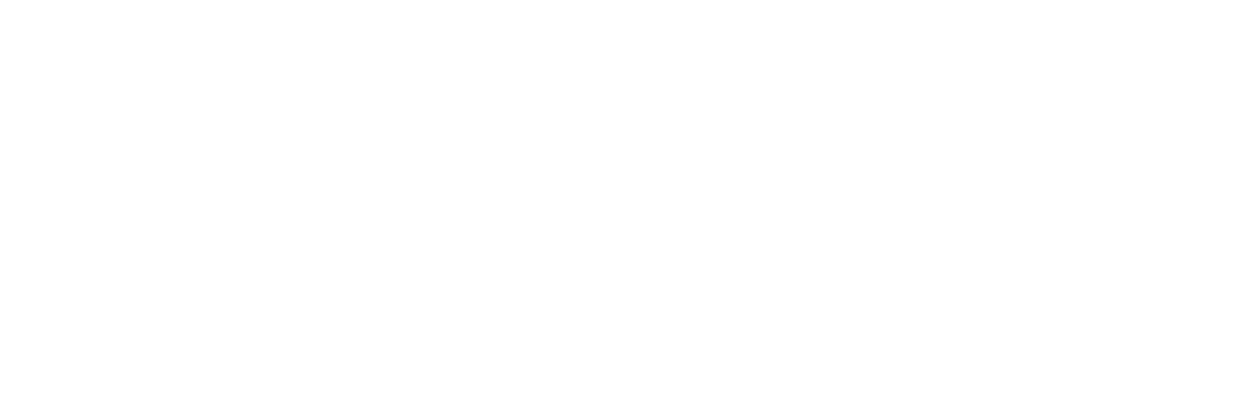

In [2]:
# ── Canvas ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 5.2))
ax.set_xlim(0, 16)
ax.set_ylim(0, 5.2)
ax.axis('off')
fig.patch.set_facecolor('white')

# ── Section labels & dashed lines ───────────────────────
ax.text(4.5, 5.05, 'PRETRAINING', ha='center', va='center',
        fontsize=9, fontweight='bold', color=COBALT, fontfamily='Arial',
        letter_spacing=1)
ax.annotate('', xy=(9.0, 5.05), xytext=(0.3, 5.05),
            arrowprops=dict(arrowstyle='-', color=COBALT, lw=0.8,
                            linestyle='dashed'))

ax.text(12.5, 5.05, 'EVALUATION', ha='center', va='center',
        fontsize=9, fontweight='bold', color=CYAN, fontfamily='Arial')
ax.annotate('', xy=(15.8, 5.05), xytext=(9.2, 5.05),
            arrowprops=dict(arrowstyle='-', color=CYAN, lw=0.8,
                            linestyle='dashed'))

# ── WSI image ───────────────────────────────────────────
wsi_ax = ax.inset_axes([0.3/16, 1.4/5.2, 1.8/16, 1.8/5.2])
wsi_ax.imshow(slide_arr)
wsi_ax.axis('off')
for spine in wsi_ax.spines.values():
    spine.set_visible(True)
    spine.set_edgecolor(GRAY_BORDER)
    spine.set_linewidth(1.0)

ax.text(1.2, 1.2, '12K TCGA WSIs', ha='center', va='top',
        fontsize=9, fontweight='bold', color=DARK_TEXT)
ax.text(1.2, 0.95, 'FFPE · H&E stained', ha='center', va='top',
        fontsize=8, color=GRAY_TEXT)

# ── Arrow 1 ─────────────────────────────────────────────
arrow(ax, 2.15, 2.3, 2.55, 2.3)

# ── Patch grid 2x2 ──────────────────────────────────────
patch_positions = [(2.6, 2.95), (3.5, 2.95), (2.6, 1.95), (3.5, 1.95)]
patch_size = [0.85/16, 0.85/5.2]
for idx, (px, py) in enumerate(patch_positions):
    p_ax = ax.inset_axes([px/16, py/5.2, patch_size[0], patch_size[1]])
    p_ax.imshow(patch_arrs[idx])
    p_ax.axis('off')

rbox(ax, 2.58, 1.93, 1.82, 1.92, fc='none', ec=GRAY_BORDER, lw=1.0, radius=0.05)

ax.text(3.5, 1.65, '25M patches', ha='center', va='top',
        fontsize=9, fontweight='bold', color=DARK_TEXT)
ax.text(3.5, 1.4, '224×224 px · offline patching', ha='center', va='top',
        fontsize=8, color=GRAY_TEXT)

# ── Arrow 2 ─────────────────────────────────────────────
arrow(ax, 4.45, 2.3, 4.85, 2.3)

# ── Model box ───────────────────────────────────────────
rbox(ax, 4.9, 0.85, 2.8, 2.9, fc=COBALT, ec=COBALT_DARK, lw=1.2, radius=0.1)

ax.text(6.3, 3.45, 'OpenMidnight', ha='center', va='center',
        fontsize=13, fontweight='bold', color='white')
ax.plot([5.1, 7.5], [3.2, 3.2], color='white', lw=0.5, alpha=0.3, zorder=4)
ax.text(6.3, 3.0, 'ViT-G/14 · 1.1B params', ha='center', va='center',
        fontsize=9, color=COBALT_LIGHT)
ax.text(6.3, 2.75, 'DINOv2 objective', ha='center', va='center',
        fontsize=9, color=COBALT_LIGHT)
ax.plot([5.1, 7.5], [2.55, 2.55], color='white', lw=0.5, alpha=0.2, zorder=4)
ax.text(6.3, 2.35, 'Pretrained init (DINOv2)', ha='center', va='center',
        fontsize=9, color=CYAN)
ax.text(6.3, 2.1, 'KDE regularizer', ha='center', va='center',
        fontsize=9, color=CYAN)
ax.text(6.3, 1.85, 'Offline patching', ha='center', va='center',
        fontsize=9, color=CYAN)
ax.plot([5.1, 7.5], [1.65, 1.65], color='white', lw=0.5, alpha=0.2, zorder=4)
ax.text(6.3, 1.4, '8×H100 · 667 GPU-hrs · $1.6K', ha='center', va='center',
        fontsize=8.5, color='white', alpha=0.75)

# ── Arrow 3 ─────────────────────────────────────────────
arrow(ax, 7.75, 2.3, 8.15, 2.3)

# ── Embedding ───────────────────────────────────────────
rbox(ax, 8.2, 1.55, 0.5, 1.5, fc=CYAN, ec=CYAN_MID, lw=1.0, radius=0.04)
for i in range(6):
    rbox(ax, 8.27, 1.62 + i*0.22, 0.36, 0.15,
         fc='white', ec='none', lw=0, radius=0.02, alpha=0.35)
ax.text(8.45, 1.35, 'embed', ha='center', va='top',
        fontsize=8.5, fontweight='bold', color=CYAN_DARK)

# ── Fan arrows to tasks ──────────────────────────────────
arrow(ax, 8.72, 2.6, 9.3, 3.8, color=CYAN)
arrow(ax, 8.72, 2.3, 9.3, 2.3, color=CYAN)
arrow(ax, 8.72, 2.0, 9.3, 0.8, color=CYAN)

# linear probe label
rbox(ax, 8.6, 2.42, 0.85, 0.22, fc='#F1F5F9', ec=GRAY_BORDER, lw=0.7, radius=0.03)
ax.text(9.02, 2.54, 'linear probe', ha='center', va='center',
        fontsize=8, color=GRAY_TEXT, style='italic')

# ── Task boxes ──────────────────────────────────────────
# Cancer classification
rbox(ax, 9.35, 3.0, 6.3, 1.5, fc=CYAN_LIGHT, ec=CYAN, lw=1.2, radius=0.08)
ax.text(9.65, 4.2, 'Cancer classification', ha='left', va='center',
        fontsize=11, fontweight='bold', color=CYAN_DARK)
ax.text(9.65, 3.85, 'Patch-level:  BACH · BRACS · BreakHis · CRC · Gleason · MHIST · PCam',
        ha='left', va='center', fontsize=8.5, color=CYAN_MID)
ax.text(9.65, 3.55, 'Slide-level:  Cam16 (small) · Panda (small)',
        ha='left', va='center', fontsize=8.5, color=CYAN_MID)

# Cell segmentation
rbox(ax, 9.35, 1.65, 6.3, 1.1, fc=CYAN_LIGHT, ec=CYAN, lw=1.2, radius=0.08)
ax.text(9.65, 2.45, 'Cell segmentation', ha='left', va='center',
        fontsize=11, fontweight='bold', color=CYAN_DARK)
ax.text(9.65, 2.1, 'Patch-level:  CoNSeP · MoNuSAC',
        ha='left', va='center', fontsize=8.5, color=CYAN_MID)

# Gene expression
rbox(ax, 9.35, 0.3, 6.3, 1.1, fc=CYAN_LIGHT, ec=CYAN, lw=1.2, radius=0.08)
ax.text(9.65, 1.1, 'Gene expression prediction', ha='left', va='center',
        fontsize=11, fontweight='bold', color=CYAN_DARK)
ax.text(9.65, 0.75, 'Patch-level:  HEST · 9 tasks · Pearson correlation',
        ha='left', va='center', fontsize=8.5, color=CYAN_MID)

# ── Bottom note ──────────────────────────────────────────
ax.text(8.0, 0.08, 'Evaluated on EVA and HEST benchmarks — patch-level and slide-level tasks',
        ha='center', va='bottom', fontsize=8, color='#94A3B8', style='italic')

plt.tight_layout()
plt.savefig('architecture_final.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
